In [38]:
# Importación de librerías.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
# Carga de los datasets.
df1 = pd.read_csv('CSVs/1- number-oil-spills.csv',sep=',')
df2 = pd.read_csv('CSVs/2- quantity-oil-spills.csv',sep=',')
df3 = pd.read_csv('CSVs/3- large-oil-spills-decadal.csv',sep=',')
df4 = pd.read_csv('CSVs/4- quantity-oil-spills-decadal-average.csv',sep=',')
df5 = pd.read_csv('CSVs/5- number-of-tanker-spills-by-operation-at-time-of-incident-1970-2022.csv',sep=',')
df6 = pd.read_csv('CSVs/6- number-of-tanker-spills-by-primary-cause-of-spill-1970-2022.csv',sep=',')

In [40]:
# Realizo un concat de los 5 DataSet para unificar en uno solo.

# Hago un merge de los primero 4 csv.
df1_4 = pd.merge(df1,df2,on=['Entity','Code','Year'],how='left').merge(df3,on=['Entity','Code','Year'],how='left').merge(df4,on=['Entity','Code','Year'],how='left')

# Hago un merge de los 2 últimos csv.
df5_6 = pd.merge(df5,df6,on=['Entity','Code','Year'],how='left')

# Por último, concateno los DataFrame anteriormente obtenido.
df = pd.concat([df1_4,df5_6],keys='Code',ignore_index=True)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14604\459852797.py:10: FutureWarning: The behavior of pd.concat with len(keys) != len(objs) is deprecated. In a future version this will raise instead of truncating to the smaller of the two sequences
  df = pd.concat([df1_4,df5_6],keys='Code',ignore_index=True)


# Verificación de los Datos Iniciales

In [41]:
# Visualización de las primeras 5 filas.
df.head()

,Entity,Code,Year,Large oil spills (>700 tonnes),Medium oil spills (7-700 tonnes),Quantity of oil spilled,Decadal large oil spills (>700 tonnes),Decadal medium oil spills (7-700 tonnes),Decadal quantity of oil spilled,At anchor (inland) operations,...,Loading/discharging operations,Underway (inland) operations,Unknown operations,Allision/collision causes,Fire/explosion causes,Hull failure causes,Unknown causes,Equipment failure causes,Grounding causes,Other causes
0,World,OWID_WRL,1970,29.0,7.0,383000.0,24.0,54.0,319500.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,World,OWID_WRL,1971,14.0,18.0,144000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,World,OWID_WRL,1972,27.0,48.0,313000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,World,OWID_WRL,1973,31.0,28.0,159000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,World,OWID_WRL,1974,27.0,90.0,174000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
# Visualización de las últimas 5 filas.
df.tail()

,Entity,Code,Year,Large oil spills (>700 tonnes),Medium oil spills (7-700 tonnes),Quantity of oil spilled,Decadal large oil spills (>700 tonnes),Decadal medium oil spills (7-700 tonnes),Decadal quantity of oil spilled,At anchor (inland) operations,...,Loading/discharging operations,Underway (inland) operations,Unknown operations,Allision/collision causes,Fire/explosion causes,Hull failure causes,Unknown causes,Equipment failure causes,Grounding causes,Other causes
50,World,OWID_WRL,2020,0.0,4.0,1000.0,1.0,4.0,8667.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,World,OWID_WRL,2021,1.0,5.0,10000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,World,OWID_WRL,2022,3.0,4.0,15000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,Large (>700t),NaN,2022,NaN,NaN,NaN,NaN,NaN,NaN,20.0,...,42.0,82.0,NaN,140.0,54.0,60.0,13.0,19.0,150.0,34.0
54,Medium (7-700t),NaN,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,399.0,NaN,764.0,367.0,51.0,101.0,207.0,214.0,271.0,180.0


In [43]:
# Dimensión del DataFrame.
print(df.shape)

(55, 24)


In [44]:
# Nombre de los atributos.
print(df.columns)

Index(['Entity', 'Code', 'Year', 'Large oil spills (>700 tonnes)',
       'Medium oil spills (7-700 tonnes)', 'Quantity of oil spilled',
       'Decadal large oil spills (>700 tonnes)',
       'Decadal medium oil spills (7-700 tonnes)',
       'Decadal quantity of oil spilled', 'At anchor (inland) operations',
       'Bunkering operations', 'Other operations',
       'Underway (open water) operations', 'At anchor (open water) operations',
       'Loading/discharging operations', 'Underway (inland) operations',
       'Unknown operations', 'Allision/collision causes',
       'Fire/explosion causes', 'Hull failure causes', 'Unknown causes',
       'Equipment failure causes', 'Grounding causes', 'Other causes'],
      dtype='object')


In [45]:
# Obtengo info del DataFrame obtenido.
from functions.info import infoDataFrame
from functions.nulls import cantidadDeNaN
infoDataFrame(df)
cantidadDeNaN(df)

-- INFO --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 24 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Entity                                    55 non-null     object 
 1   Code                                      53 non-null     object 
 2   Year                                      55 non-null     int64  
 3   Large oil spills (>700 tonnes)            53 non-null     float64
 4   Medium oil spills (7-700 tonnes)          53 non-null     float64
 5   Quantity of oil spilled                   53 non-null     float64
 6   Decadal large oil spills (>700 tonnes)    6 non-null      float64
 7   Decadal medium oil spills (7-700 tonnes)  6 non-null      float64
 8   Decadal quantity of oil spilled           6 non-null      float64
 9   At anchor (inland) operations             1 non-null      float64
 10  Bunkering operations         

# Insights
#### - Posee valores nulos.
#### - Las columnas Entity y Code son del tipo "Object", Year es del tipo "int64" y el resto es del tipo "float64"


## DATA CLEANING

In [46]:
# Creo una copia del DataFrame.
copy_df = df.copy()
# Utilizo la columna "Year" como indice
df.index = df['Year']
df.drop(['Year'],axis=1, inplace=True)
df

,Entity,Code,Large oil spills (>700 tonnes),Medium oil spills (7-700 tonnes),Quantity of oil spilled,Decadal large oil spills (>700 tonnes),Decadal medium oil spills (7-700 tonnes),Decadal quantity of oil spilled,At anchor (inland) operations,Bunkering operations,...,Loading/discharging operations,Underway (inland) operations,Unknown operations,Allision/collision causes,Fire/explosion causes,Hull failure causes,Unknown causes,Equipment failure causes,Grounding causes,Other causes
Year,,,,,,,,,,,,,,,,,,,,,
1970,World,OWID_WRL,29.0,7.0,383000.0,24.0,54.0,319500.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1971,World,OWID_WRL,14.0,18.0,144000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972,World,OWID_WRL,27.0,48.0,313000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1973,World,OWID_WRL,31.0,28.0,159000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1974,World,OWID_WRL,27.0,90.0,174000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975,World,OWID_WRL,20.0,96.0,352000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976,World,OWID_WRL,26.0,67.0,365000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1977,World,OWID_WRL,16.0,70.0,276000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978,World,OWID_WRL,23.0,59.0,393000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
# Relleno los Valores nulos con ceros.
df.fillna(0)

,Entity,Code,Large oil spills (>700 tonnes),Medium oil spills (7-700 tonnes),Quantity of oil spilled,Decadal large oil spills (>700 tonnes),Decadal medium oil spills (7-700 tonnes),Decadal quantity of oil spilled,At anchor (inland) operations,Bunkering operations,...,Loading/discharging operations,Underway (inland) operations,Unknown operations,Allision/collision causes,Fire/explosion causes,Hull failure causes,Unknown causes,Equipment failure causes,Grounding causes,Other causes
Year,,,,,,,,,,,,,,,,,,,,,
1970,World,OWID_WRL,29.0,7.0,383000.0,24.0,54.0,319500.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1971,World,OWID_WRL,14.0,18.0,144000.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1972,World,OWID_WRL,27.0,48.0,313000.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1973,World,OWID_WRL,31.0,28.0,159000.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1974,World,OWID_WRL,27.0,90.0,174000.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1975,World,OWID_WRL,20.0,96.0,352000.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1976,World,OWID_WRL,26.0,67.0,365000.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1977,World,OWID_WRL,16.0,70.0,276000.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1978,World,OWID_WRL,23.0,59.0,393000.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
# Guardo en un archivos .csv
df.to_csv('oilSpill.csv',sep=';')

## EDA

In [49]:
# Realizo un Describe del DataFrame
from functions.describe import decripcionDF
decripcionDF(df)

--DECRIBE--


       Large oil spills (>700 tonnes)  Medium oil spills (7-700 tonnes)  \
count                       53.000000                         53.000000   
mean                         8.867925                         26.245283   
std                          8.801306                         22.764603   
min                          0.000000                          2.000000   
25%                          3.000000                          7.000000   
50%                          5.000000                         20.000000   
75%                         13.000000                         32.000000   
max                         32.000000                         96.000000   

       Quantity of oil spilled  Decadal large oil spills (>700 tonnes)  \
count                53.000000                                6.000000   
mean             111132.075472                                7.833333   
std              146228.882464                                8.565434   
min           

## VISUALIZACIÓN

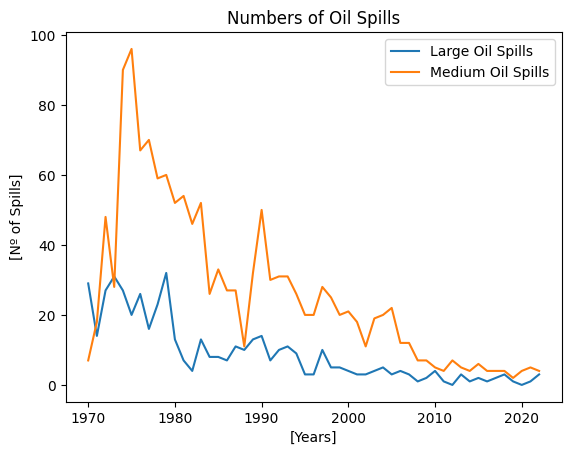

In [50]:
# Graficos
# Plot "Número de Derrames superando los 700 toneles"

fig,ax = plt.subplots()
ax.plot(df.index, df['Large oil spills (>700 tonnes)'],label="Large Oil Spills")
ax.plot(df.index, df['Medium oil spills (7-700 tonnes)'],label="Medium Oil Spills")
ax.set_xlabel('[Years]')
ax.set_ylabel('[Nº of Spills]')
ax.set_title('Numbers of Oil Spills')
ax.legend()
plt.show()

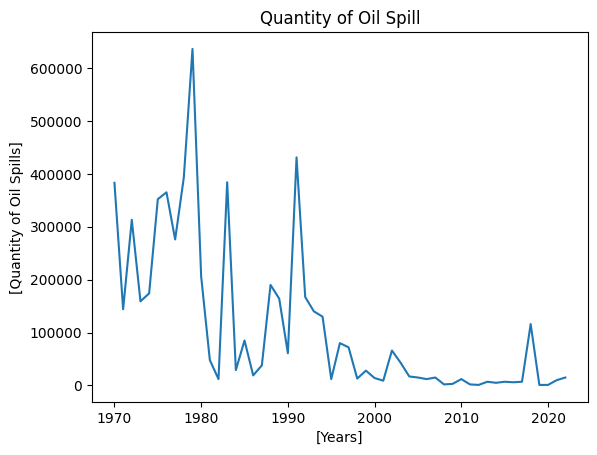

In [51]:
# Graficos
# Plot "Cantidad de Derrames superando los 700 toneles"

fig,ax = plt.subplots()
sns.lineplot(data=df,x=df.index,y='Quantity of oil spilled')
ax.set_xlabel('[Years]')
ax.set_ylabel('[Quantity of Oil Spills]')
plt.title('Quantity of Oil Spill')
plt.show()

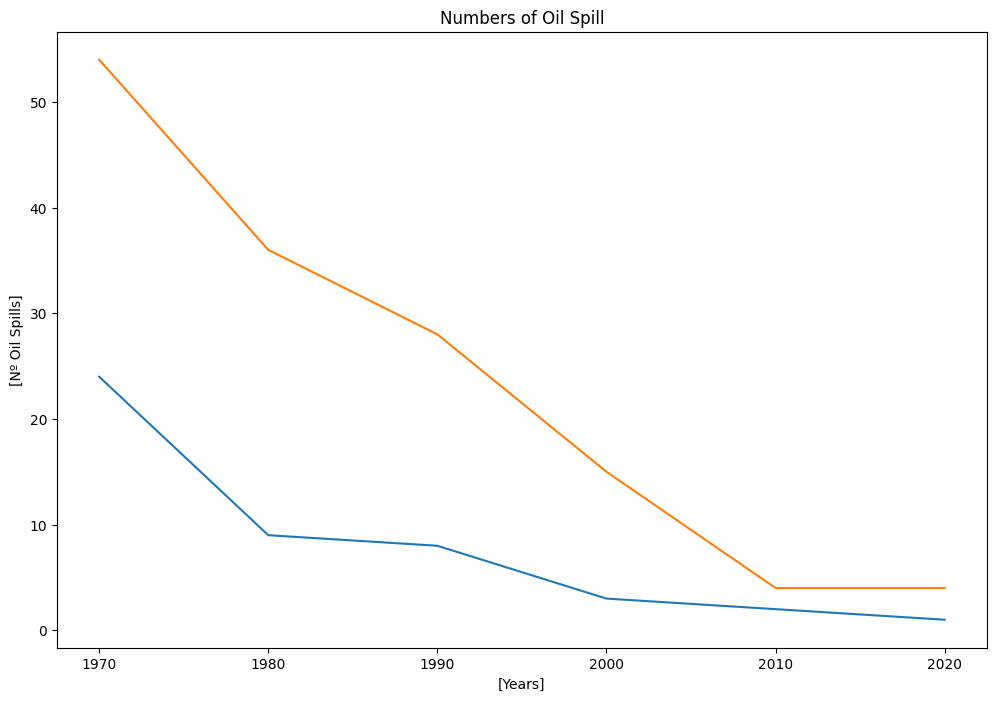

In [52]:
# Graficos
# Plot "Número de Derrames inferior a los 700 toneles"
fig,ax = plt.subplots(figsize=(12,8))
sns.lineplot(data=df,x=df.index,y='Decadal large oil spills (>700 tonnes)')
sns.lineplot(data=df,x=df.index,y='Decadal medium oil spills (7-700 tonnes)')
ax.set_xlabel('[Years]')
ax.set_ylabel('[Nº Oil Spills]')
plt.title('Numbers of Oil Spill')
plt.show()

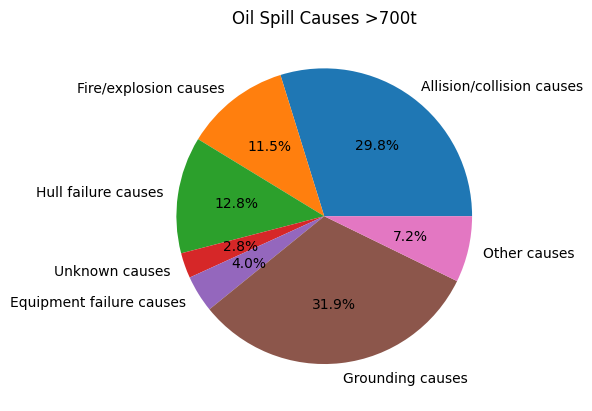

In [53]:
# Graficos
# Plot "Causas de Derrame > 700 toneladas"
largeSpill = df.loc[df['Entity'] == 'Large (>700t)',['Allision/collision causes', 'Fire/explosion causes', 'Hull failure causes', 'Unknown causes', 'Equipment failure causes', 'Grounding causes', 'Other causes']]
data = largeSpill.sum()
fig,ax = plt.subplots()
ax.pie(data,labels=data.index, autopct='%1.1f%%')
plt.title('Oil Spill Causes >700t')
plt.show()


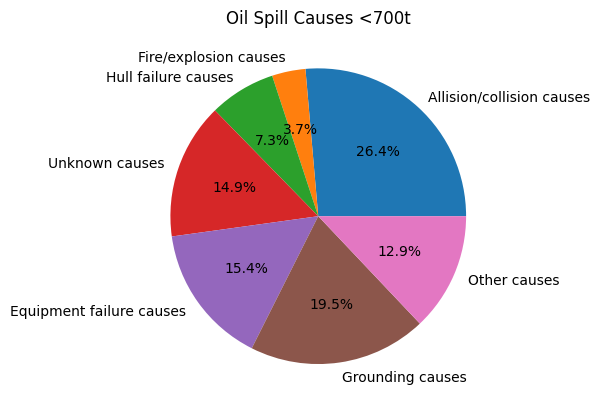

In [54]:
# Graficos
# Plot "Causas de Derrame < 700 toneladas"
mediumSpill = df.loc[df['Entity'] == 'Medium (7-700t)',['Allision/collision causes', 'Fire/explosion causes', 'Hull failure causes', 'Unknown causes', 'Equipment failure causes', 'Grounding causes', 'Other causes']]
data = mediumSpill.sum()
fig,ax = plt.subplots()
ax.pie(data,labels=data.index, autopct='%1.1f%%')
plt.title('Oil Spill Causes <700t')
plt.show()

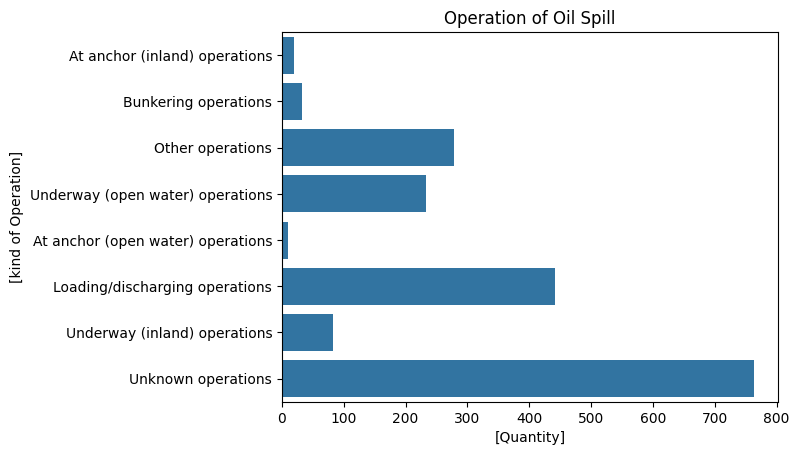

In [55]:
# Graficos
# Plot "Tipo de operaciones"

fig,ax = plt.subplots()
operations = df[['At anchor (inland) operations', 'Bunkering operations', 'Other operations', 'Underway (open water) operations', 'At anchor (open water) operations', 'Loading/discharging operations', 'Underway (inland) operations', 'Unknown operations']]
data = operations.sum()
data1 = pd.DataFrame(data, columns=['Quantity'])
data1
sns.barplot(data=data1,x=data1['Quantity'], y=data1.index)
ax.set_xlabel('[Quantity]')
ax.set_ylabel('[kind of Operation]')
plt.title('Operation of Oil Spill')
plt.show()